In [1]:
# Pour le data management 
import pandas as pd
import numpy as np

# Pour le pré processing
from unidecode import unidecode
import re
from nltk.stem import SnowballStemmer

# Les bigrammes
from collections import Counter
from nltk.util import ngrams

# Pour la vectorisation
from sklearn.feature_extraction.text import TfidfVectorizer 

# Pour la modélisation
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, recall_score, precision_score

from sklearn.naive_bayes import GaussianNB

#Pour les bibliothèques  
import matplotlib.pyplot as plt
import seaborn as sns
import cufflinks as cf
import plotly.express as px
import plotly.graph_objects as go
%matplotlib inline

# Sujet du projet :
# Réalisation d’une application Streamlit qui permet d’afficher tout ce qu’il y a à savoir sur notre jeu de données.


## Etape 1 : Nous avons choisi un jeu de données sur Kaggle qui contient à la fois des données catégorielles, des données numériques et des données temporelles

## Etape 2: Réalisation de toutes les étapes d’exploration des données & de nettoyage des données pour gérer les valeurs manquantes

In [2]:
##Lire le fichier credit_card_transactions.csv en un dataframe 

df_credit_card = pd.read_csv('credit_card_transactions.csv')

In [3]:
df_credit_card

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,28705.0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,NaN
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,83236.0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,NaN
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,22844.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,1296670,2020-06-21 12:12:08,30263540414123,fraud_Reichel Inc,entertainment,15.56,Erik,Patterson,M,162 Jessica Row Apt. 072,...,-112.4777,258,Geoscientist,1961-11-24,440b587732da4dc1a6395aba5fb41669,1371816728,36.841266,-111.690765,0,NaN
1296671,1296671,2020-06-21 12:12:19,6011149206456997,fraud_Abernathy and Sons,food_dining,51.70,Jeffrey,White,M,8617 Holmes Terrace Suite 651,...,-77.5101,100,"Production assistant, television",1979-12-11,278000d2e0d2277d1de2f890067dcc0a,1371816739,38.906881,-78.246528,0,22630.0
1296672,1296672,2020-06-21 12:12:32,3514865930894695,fraud_Stiedemann Ltd,food_dining,105.93,Christopher,Castaneda,M,1632 Cohen Drive Suite 639,...,-105.8189,899,Naval architect,1967-08-30,483f52fe67fabef353d552c1e662974c,1371816752,33.619513,-105.130529,0,88351.0
1296673,1296673,2020-06-21 12:13:36,2720012583106919,"fraud_Reinger, Weissnat and Strosin",food_dining,74.90,Joseph,Murray,M,42933 Ryan Underpass,...,-102.5411,1126,Volunteer coordinator,1980-08-18,d667cdcbadaaed3da3f4020e83591c83,1371816816,42.788940,-103.241160,0,69367.0


In [4]:
##Afficher les dimensions de ce DataFrame 
df_credit_card.shape

(1296675, 24)

**A propos de ce dataset :**

Origine
   - Ces données proviennent de la base de données Kaggle 

Description : 

   - L'ensemble de données sur les transactions par carte de crédit fournit des enregistrements détaillés des transactions par carte de crédit,
y compris des informations sur les heures de transaction, les montants et les informations personnelles et commerciales associées. 
Cet ensemble de données contient plus de 1 millions million de lignes.

Format
  - Un bloc de données avec 1 296 675 lignes et 24 variables

Details :
    
 - trans_date_trans_time:Horodatage de la transaction.
    
 - cc_num:  Numéro de carte de crédit (haché ou anonymisé)

 - merchant: Commerçant ou magasin où la transaction a eu lieu
     
 - category : Type de transaction (par exemple, épicerie, divertissement)

 - am : Montant de la transaction

 - first: Prénom du titulaire de la carte

 - last: Nom de famille du titulaire de la carte
     
 - gende : Sexe du titulaire de la carte
     
 - street : Rue ou habite le titulaire de la carte 

 - city :  Ville ou habite le titulaire de la carte 

 - state : Etat dans lequel habite le titulaire de la carte 

 - zip : Code postale du titulaire de la carte 

 - lat:  Lieu precis de l'achat au nord ou Sud

 - long : Lieu précis de l'achat à l'Est ou Ouest  

 - city_pop : Population de la ville où la transaction a eu lieu

 - job : Profession du titulaire de la carte.

 - dob : Date de naissance du titulaire de la carte

 - trans_num : Numéro de transaction unique

 - unix_time : Horodatage Unix de la transaction

 - merch_lat : Lieu precis du commerçant au Nord ou Sud  

 - merch_long : Lieu precis du commerçant à l'Est ou Ouest 

 - is_fraud : Indicateur indiquant si la transaction est frauduleuse.

 - merch_zipcode : Code postale du commerçant 
   

In [5]:
## Afficher les informations consises du DataFrame 
df_credit_card.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 24 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [6]:
## Selection & détection des valeurs manquantes 
df_credit_card.isnull()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1296671,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1296672,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1296673,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [7]:
#Nombre de valeurs manquantes par colonnes 
df_credit_card.isnull().sum() 

Unnamed: 0                    0
trans_date_trans_time         0
cc_num                        0
merchant                      0
category                      0
amt                           0
first                         0
last                          0
gender                        0
street                        0
city                          0
state                         0
zip                           0
lat                           0
long                          0
city_pop                      0
job                           0
dob                           0
trans_num                     0
unix_time                     0
merch_lat                     0
merch_long                    0
is_fraud                      0
merch_zipcode            195973
dtype: int64

In [8]:
#Supprimer les valeurs manquantes 
df_credit_card.dropna(inplace=True)

In [9]:
df_credit_card

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,28705.0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,83236.0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,22844.0
5,5,2019-01-01 00:04:08,4767265376804500,"fraud_Stroman, Hudson and Erdman",gas_transport,94.63,Jennifer,Conner,F,4655 David Island,...,-75.2045,2158,Transport planner,1961-06-19,189a841a0a8ba03058526bcfe566aab5,1325376248,40.653382,-76.152667,0,17972.0
7,7,2019-01-01 00:05:08,6011360759745864,fraud_Corwin-Collins,gas_transport,71.65,Steven,Williams,M,231 Flores Pass Suite 720,...,-78.6003,6018,"Designer, multimedia",1947-08-21,6d294ed2cc447d2c71c7171a3d54967c,1325376308,38.948089,-78.540296,0,22644.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296669,1296669,2020-06-21 12:11:36,4400011257587661852,fraud_Stiedemann Inc,misc_pos,37.38,Marissa,Powell,F,474 Allen Haven,...,-98.7858,509,"Nurse, children's",1980-09-15,9a7ea2625cf8303efe34e3c09546868f,1371816696,41.728638,-99.039660,0,68837.0
1296671,1296671,2020-06-21 12:12:19,6011149206456997,fraud_Abernathy and Sons,food_dining,51.70,Jeffrey,White,M,8617 Holmes Terrace Suite 651,...,-77.5101,100,"Production assistant, television",1979-12-11,278000d2e0d2277d1de2f890067dcc0a,1371816739,38.906881,-78.246528,0,22630.0
1296672,1296672,2020-06-21 12:12:32,3514865930894695,fraud_Stiedemann Ltd,food_dining,105.93,Christopher,Castaneda,M,1632 Cohen Drive Suite 639,...,-105.8189,899,Naval architect,1967-08-30,483f52fe67fabef353d552c1e662974c,1371816752,33.619513,-105.130529,0,88351.0
1296673,1296673,2020-06-21 12:13:36,2720012583106919,"fraud_Reinger, Weissnat and Strosin",food_dining,74.90,Joseph,Murray,M,42933 Ryan Underpass,...,-102.5411,1126,Volunteer coordinator,1980-08-18,d667cdcbadaaed3da3f4020e83591c83,1371816816,42.788940,-103.241160,0,69367.0


In [10]:
#Afficher des statistiques descriptives du DataFrame 
df_credit_card.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
count,1.100702e+06,1.100702e+06,1.100702e+06,1.100702e+06,1.100702e+06,1.100702e+06,1.100702e+06,1.100702e+06,1.100702e+06,1.100702e+06,1.100702e+06,1.100702e+06
mean,6.484093e+05,4.161295e+17,7.024263e+01,4.667787e+04,3.853642e+01,-8.880816e+01,8.718006e+04,1.349246e+09,3.854538e+01,-8.881376e+01,5.780856e-03,4.682575e+04
std,3.742985e+05,1.307304e+18,1.614206e+02,2.594620e+04,4.571236e+00,1.229043e+01,2.986316e+05,1.284034e+07,4.577577e+00,1.228787e+01,7.581189e-02,2.583400e+04
min,0.000000e+00,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.554880e+02,2.300000e+01,1.325376e+09,1.935247e+01,-1.564877e+02,0.000000e+00,1.001000e+03
25%,3.243012e+05,1.800400e+14,9.640000e+00,2.443300e+04,3.498890e+01,-9.535090e+01,7.760000e+02,1.338753e+09,3.506480e+01,-9.538574e+01,0.000000e+00,2.511400e+04
50%,6.484065e+05,3.521417e+15,4.754000e+01,4.580800e+04,3.928300e+01,-8.655100e+01,2.456000e+03,1.349254e+09,3.931189e+01,-8.669550e+01,0.000000e+00,4.586000e+04
75%,9.727038e+05,4.635331e+15,8.316000e+01,6.862600e+04,4.156860e+01,-7.986270e+01,1.876000e+04,1.359397e+09,4.167489e+01,-7.987686e+01,0.000000e+00,6.831900e+04
max,1.296674e+06,4.992346e+18,2.894890e+04,9.932300e+04,4.888780e+01,-6.795030e+01,2.906700e+06,1.371817e+09,4.912822e+01,-6.695600e+01,1.000000e+00,9.940300e+04


In [11]:
## Transporer le DF pour une bonne analyse 
df_credit_card.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,1100702.0,6.484093e+05,3.742985e+05,0.000000e+00,3.243012e+05,6.484065e+05,9.727038e+05,1.296674e+06
cc_num,1100702.0,4.161295e+17,1.307304e+18,6.041621e+10,1.800400e+14,3.521417e+15,4.635331e+15,4.992346e+18
amt,1100702.0,7.024263e+01,1.614206e+02,1.000000e+00,9.640000e+00,4.754000e+01,8.316000e+01,2.894890e+04
zip,1100702.0,4.667787e+04,2.594620e+04,1.257000e+03,2.443300e+04,4.580800e+04,6.862600e+04,9.932300e+04
lat,1100702.0,3.853642e+01,4.571236e+00,2.002710e+01,3.498890e+01,3.928300e+01,4.156860e+01,4.888780e+01
long,1100702.0,-8.880816e+01,1.229043e+01,-1.554880e+02,-9.535090e+01,-8.655100e+01,-7.986270e+01,-6.795030e+01
city_pop,1100702.0,8.718006e+04,2.986316e+05,2.300000e+01,7.760000e+02,2.456000e+03,1.876000e+04,2.906700e+06
unix_time,1100702.0,1.349246e+09,1.284034e+07,1.325376e+09,1.338753e+09,1.349254e+09,1.359397e+09,1.371817e+09
merch_lat,1100702.0,3.854538e+01,4.577577e+00,1.935247e+01,3.506480e+01,3.931189e+01,4.167489e+01,4.912822e+01
merch_long,1100702.0,-8.881376e+01,1.228787e+01,-1.564877e+02,-9.538574e+01,-8.669550e+01,-7.987686e+01,-6.695600e+01


## Etape 3  : Création d’au moins deux nouvelles variables en fonction des autres variables

In [50]:
df_credit_card

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,merch_lat,merch_long,is_fraud,merch_zipcode,transaction_month,transactions_per_month,transaction_hour,transactions_per_hour,age,age_group
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.011293,-82.048315,0,28705.0,2019-01,98,0,49,30,26-35
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,43.150704,-112.154481,0,83236.0,2019-01,14,0,12,56,56-65
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.674999,-78.632459,0,22844.0,2019-01,90,0,75,32,26-35
5,5,2019-01-01 00:04:08,4767265376804500,"fraud_Stroman, Hudson and Erdman",gas_transport,94.63,Jennifer,Conner,F,4655 David Island,...,40.653382,-76.152667,0,17972.0,2019-01,25,0,21,57,56-65
7,7,2019-01-01 00:05:08,6011360759745864,fraud_Corwin-Collins,gas_transport,71.65,Steven,Williams,M,231 Flores Pass Suite 720,...,38.948089,-78.540296,0,22644.0,2019-01,37,0,48,71,66-75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296669,1296669,2020-06-21 12:11:36,4400011257587661852,fraud_Stiedemann Inc,misc_pos,37.38,Marissa,Powell,F,474 Allen Haven,...,41.728638,-99.039660,0,68837.0,2020-06,67,12,97,39,36-45
1296671,1296671,2020-06-21 12:12:19,6011149206456997,fraud_Abernathy and Sons,food_dining,51.70,Jeffrey,White,M,8617 Holmes Terrace Suite 651,...,38.906881,-78.246528,0,22630.0,2020-06,20,12,29,40,36-45
1296672,1296672,2020-06-21 12:12:32,3514865930894695,fraud_Stiedemann Ltd,food_dining,105.93,Christopher,Castaneda,M,1632 Cohen Drive Suite 639,...,33.619513,-105.130529,0,88351.0,2020-06,34,12,20,52,46-55
1296673,1296673,2020-06-21 12:13:36,2720012583106919,"fraud_Reinger, Weissnat and Strosin",food_dining,74.90,Joseph,Murray,M,42933 Ryan Underpass,...,42.788940,-103.241160,0,69367.0,2020-06,56,12,70,39,36-45


# Analyse temporelle des transactions 

In [19]:
# Créer une variable month à partir de transaction_per_month

# Convertir 'trans_date_trans_time' en datetime 
df_credit_card['trans_date_trans_time'] = pd.to_datetime(df_credit_card['trans_date_trans_time'], errors='coerce')

# Ajouter une colonne de mois à partir de 'trans_date_trans_time'
df_credit_card['transaction_month'] = df_credit_card['trans_date_trans_time'].dt.to_period('M')

# Calculer le nombre de transactions par mois pour chaque utilisateur
df_credit_card['transactions_per_month'] = df_credit_card.groupby(['cc_num', 'transaction_month'])['trans_num'].transform('count')

# Afficher 
df_credit_card.head()


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode,transaction_month,transactions_per_month
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,28705.0,2019-01,98
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,83236.0,2019-01,14
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,22844.0,2019-01,90
5,5,2019-01-01 00:04:08,4767265376804500,"fraud_Stroman, Hudson and Erdman",gas_transport,94.63,Jennifer,Conner,F,4655 David Island,...,Transport planner,1961-06-19,189a841a0a8ba03058526bcfe566aab5,1325376248,40.653382,-76.152667,0,17972.0,2019-01,25
7,7,2019-01-01 00:05:08,6011360759745864,fraud_Corwin-Collins,gas_transport,71.65,Steven,Williams,M,231 Flores Pass Suite 720,...,"Designer, multimedia",1947-08-21,6d294ed2cc447d2c71c7171a3d54967c,1325376308,38.948089,-78.540296,0,22644.0,2019-01,37


In [20]:
# Créer une variable heure de la journéé à partir de transaction_hour

# Ajouter une colonne d'heure à partir de 'trans_date_trans_time'
df_credit_card['transaction_hour'] = df_credit_card['trans_date_trans_time'].dt.hour

# Calculer le nombre de transactions par heure pour chaque utilisateur
df_credit_card['transactions_per_hour'] = df_credit_card.groupby(['cc_num', 'transaction_hour'])['trans_num'].transform('count')

# Afficher 
df_credit_card.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode,transaction_month,transactions_per_month,transaction_hour,transactions_per_hour
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,28705.0,2019-01,98,0,49
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,83236.0,2019-01,14,0,12
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,22844.0,2019-01,90,0,75
5,5,2019-01-01 00:04:08,4767265376804500,"fraud_Stroman, Hudson and Erdman",gas_transport,94.63,Jennifer,Conner,F,4655 David Island,...,189a841a0a8ba03058526bcfe566aab5,1325376248,40.653382,-76.152667,0,17972.0,2019-01,25,0,21
7,7,2019-01-01 00:05:08,6011360759745864,fraud_Corwin-Collins,gas_transport,71.65,Steven,Williams,M,231 Flores Pass Suite 720,...,6d294ed2cc447d2c71c7171a3d54967c,1325376308,38.948089,-78.540296,0,22644.0,2019-01,37,0,48


# Analyse géographique des transactions 

In [21]:
# Cacule du nombre de transactions par ville 
transactions_by_city = df_credit_card.groupby('city').size()
transactions_by_city

city
Achille                       527
Acworth                      2085
Adams                         493
Afton                        1808
Akron                         441
                             ... 
Woods Cross                   323
Woodville                    2097
Yellowstone National Park     205
Zaleski                      1557
Zavalla                      1381
Length: 891, dtype: int64

In [22]:
# Cacule du nombre de transactions par Etat 
transactions_by_state = df_credit_card.groupby('state').size()
transactions_by_state.head()

state
AL    38696
AR    30424
AZ     6291
CA    39928
CO    10025
dtype: int64

# Analyse démographique des titulaires de carte 

In [23]:
# Calculer le nombre de transactions en fonction du sexe des clients.
total_amount_by_gender = df_credit_card.groupby('gender')['amt'].sum()
total_amount_by_gender

gender
F    41959230.79
M    35356967.13
Name: amt, dtype: float64

In [24]:
# calculer l'age moyen  des titulaires de carte par catégorie de transaction

# Calculer l'âge des titulaires de carte
df_credit_card['dob'] = pd.to_datetime(df_credit_card['dob'])  
df_credit_card['trans_date_trans_time'] = pd.to_datetime(df_credit_card['trans_date_trans_time'])
df_credit_card['age'] = (df_credit_card['trans_date_trans_time'] - df_credit_card['dob']).dt.days // 365

# Calculer l'âge moyen des titulaires de carte par catégorie de transaction
average_age_by_category = df_credit_card.groupby('category')['age'].mean().reset_index(name='average_cardholder_age')

average_age_by_category


,category,average_cardholder_age
0,entertainment,45.843564
1,food_dining,44.571155
2,gas_transport,47.726717
3,grocery_net,38.452073
4,grocery_pos,46.737855
5,health_fitness,45.674313
6,home,46.514502
7,kids_pets,46.926746
8,misc_net,45.906124
9,misc_pos,43.881437


In [90]:
# Repartition des professions des titulaires de carte par sex et par age  
job_by_gender_age = df_credit_card.groupby(['gender', 'age', 'job']).size().reset_index(name='transaction_count')
job_by_gender_age

,gender,age,job,transaction_count
0,F,14,"Lecturer, higher education",114
1,F,14,"Psychotherapist, child",512
2,F,14,Secondary school teacher,1701
3,F,15,"Lecturer, higher education",366
4,F,15,"Psychotherapist, child",1987
...,...,...,...,...
2290,M,92,TEFL teacher,11
2291,M,93,Facilities manager,1396
2292,M,94,"Conservator, furniture",280
2293,M,94,Facilities manager,77


### Determiner la repartition des titulaires de carte par tranche d'age  et par profession

In [88]:
# Définir les tranches d'âge
bins = [18, 25, 35, 45, 55, 65, 100]  # Tranches d'âge
labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '66+']  # Noms des tranches d'âge

# Créer une nouvelle colonne 'age_group' pour attribuer chaque âge à une tranche
df_credit_card['Tranche age'] = pd.cut(df_credit_card['age'], bins=bins, labels=labels, right=False)

# Calculer la répartition par tranche d'âge et par profession avec observed=False
age_job_distribution = df_credit_card.groupby(['age_group', 'job'], observed=False).size().reset_index(name='count')

# Afficher le résultat
age_job_distribution

,age_group,job,count
0,18-25,Academic librarian,0
1,18-25,"Accountant, chartered",0
2,18-25,"Accountant, chartered certified",0
3,18-25,"Accountant, chartered public finance",0
4,18-25,Accounting technician,0
...,...,...,...
2953,66+,Water engineer,0
2954,66+,Water quality scientist,0
2955,66+,Web designer,1436
2956,66+,Wellsite geologist,0


### Determiner les depenses moyennes par âge et par sex

In [89]:
# Calculer les dépenses moyennes par âge et par sexe
avg_spending_by_age_and_gender = df_credit_card.groupby(['age', 'gender'])['amt'].mean().unstack()

avg_spending_by_age_and_gender = avg_spending_by_age_and_gender.fillna(0)

avg_spending_by_age_and_gender

gender,F,M
age,,
13,0.000000,71.688406
14,53.776571,70.773262
15,69.562476,58.527009
16,68.877637,69.259347
17,59.423705,76.435492
...,...,...
91,70.051249,71.198904
92,74.845014,60.845760
93,66.826046,60.929814


# Analyse par catégorie de transaction ( Commerçant ou catégorie)

In [27]:
# Le montants total des transactions par catégories 

total_amount_by_category = df_credit_card.groupby('category')['amt'].sum()

total_amount_by_category

category
entertainment      5116218.62
food_dining        3977089.87
gas_transport      7134452.04
grocery_net        2055404.61
grocery_pos       12224385.74
health_fitness     3945387.59
home               6080632.49
kids_pets          5525300.48
misc_net           4327865.94
misc_pos           4227774.11
personal_care      3696173.14
shopping_net       7285106.05
shopping_pos       7874704.92
travel             3845702.32
Name: amt, dtype: float64

In [29]:
# Nombre de transactions par commerçant 
transactions_by_merchant = df_credit_card.groupby('merchant').size()
 
transactions_by_merchant

merchant
fraud_Abbott-Rogahn                 1569
fraud_Abbott-Steuber                1503
fraud_Abernathy and Sons            1503
fraud_Abshire PLC                   1616
fraud_Adams, Kovacek and Kuhlman     813
                                    ... 
fraud_Zemlak Group                  1091
fraud_Zemlak, Tillman and Cremin    1534
fraud_Ziemann-Waters                1444
fraud_Zieme, Bode and Dooley        2198
fraud_Zulauf LLC                    1505
Length: 693, dtype: int64

In [30]:
# Nombre de transactions par categorie
transactions_by_category = df_credit_card.groupby('category').size()
transactions_by_category

category
entertainment      79956
food_dining        77767
gas_transport     112473
grocery_net        38308
grocery_pos       104942
health_fitness     72849
home              104295
kids_pets          95954
misc_net           53475
misc_pos           67694
personal_care      77088
shopping_net       82440
shopping_pos       98958
travel             34503
dtype: int64

In [31]:
# Calcule du montant moyen par catégorie
avg_amount_by_category = df_credit_card.groupby('category')['amt'].mean()
avg_amount_by_category

category
entertainment      63.987926
food_dining        51.141099
gas_transport      63.432575
grocery_net        53.654709
grocery_pos       116.487067
health_fitness     54.158432
home               58.302244
kids_pets          57.582805
misc_net           80.932509
misc_pos           62.454193
personal_care      47.947451
shopping_net       88.368584
shopping_pos       79.576234
travel            111.459940
Name: amt, dtype: float64

# Détection de fraude

### Analyse des transactions frauduleuses 

In [54]:
# Detection de fraude : Comparer les caractéristiques des transactions frauduleuses (is_fraud) versus non frauduleuses, telles que le montant, la localisation, ou le type de commerçant.

# Séparer les transactions frauduleuses et non frauduleuses
fraudulent_transactions = df_credit_card[df_credit_card['is_fraud'] == 1]
non_fraudulent_transactions = df_credit_card[df_credit_card['is_fraud'] == 0]

# Comparer les montants moyens
avg_amount_fraud = fraudulent_transactions['amt'].mean()
avg_amount_non_fraud = non_fraudulent_transactions['amt'].mean()

# Comparer les commerçants les plus impliqués
top_merchants_fraud = fraudulent_transactions['merchant'].value_counts().head(5)
top_merchants_non_fraud = non_fraudulent_transactions['merchant'].value_counts().head(5)

# Comparer les localisations les plus fréquentes
top_states_fraud = fraudulent_transactions['state'].value_counts().head(5)
top_states_non_fraud = non_fraudulent_transactions['state'].value_counts().head(5)

# Résumé des informations dans un dictionnaire
fraud_analysis = {
    "Montant moyen (frauduleux)": avg_amount_fraud,
    "Montant moyen (non frauduleux)": avg_amount_non_fraud,
    "Top 5 commerçants (frauduleux)": top_merchants_fraud,
    "Top 5 commerçants (non frauduleux)": top_merchants_non_fraud,
    "Top 5 états (frauduleux)": top_states_fraud,
    "Top 5 états (non frauduleux)": top_states_non_fraud
}

# Afficher
fraud_analysis


{'Montant moyen (frauduleux)': 531.0259107339306,
 'Montant moyen (non frauduleux)': 67.56341503866717,
 'Top 5 commerçants (frauduleux)': merchant
 fraud_Rau and Sons       44
 fraud_Cormier LLC        42
 fraud_Doyle Ltd          41
 fraud_Vandervort-Funk    41
 fraud_Kozey-Boehm        41
 Name: count, dtype: int64,
 'Top 5 commerçants (non frauduleux)': merchant
 fraud_Kilback LLC    3702
 fraud_Cormier LLC    3066
 fraud_Schumm PLC     3057
 fraud_Boyer PLC      2949
 fraud_Kuhn LLC       2936
 Name: count, dtype: int64,
 'Top 5 états (frauduleux)': state
 NY    461
 PA    440
 TX    370
 OH    312
 IL    243
 Name: count, dtype: int64,
 'Top 5 états (non frauduleux)': state
 PA    77599
 TX    76085
 NY    70296
 OH    44165
 IL    41787
 Name: count, dtype: int64}

### Determiner la ville ou le taux de fraude est plus élévé.

In [33]:
# Determiner les villes ou il y'a le taux de fraude le plus élevé de fraude

# Calculer le nombre total de transactions par ville
total_transactions_by_city = df_credit_card.groupby('city')['is_fraud'].count()

# Calculer le nombre de transactions frauduleuses par ville
fraud_transactions_by_city = df_credit_card[df_credit_card['is_fraud'] == 1].groupby('city')['is_fraud'].count()

# Calculer le taux de fraude par ville
fraud_rate_by_city = (fraud_transactions_by_city / total_transactions_by_city) * 100

# Trier les villes par taux de fraude décroissant
fraud_rate_by_city = fraud_rate_by_city.sort_values(ascending=False)

# Afficher les 10 premières villes avec le taux de fraude le plus élevé
fraud_rate_by_city.head(10)

city
Gaines           100.0
Beacon           100.0
Claypool         100.0
Clinton          100.0
Nanuet           100.0
Mountain City    100.0
Mount Vernon     100.0
Moss Point       100.0
Morven           100.0
Marshall         100.0
Name: is_fraud, dtype: float64

### Determiner le taux de fraude par catégorie de transaction ou par commerçant.

In [34]:
# Determiner le taux de fraude par catégorie de transaction 

# Calculer le nombre total de transactions par catégorie
total_transactions_by_category = df_credit_card.groupby('category')['is_fraud'].count()

# Calculer le nombre de transactions frauduleuses par catégorie
fraud_transactions_by_category = df_credit_card[df_credit_card['is_fraud'] == 1].groupby('category')['is_fraud'].count()

# Calculer le taux de fraude par catégorie
fraud_rate_by_category = (fraud_transactions_by_category / total_transactions_by_category) * 100

# Remplir les catégories sans fraude avec 0 
fraud_rate_by_category = fraud_rate_by_category.fillna(0)

# Afficher le taux de fraude par catégorie
fraud_rate_by_category

category
entertainment     0.263895
food_dining       0.159451
gas_transport     0.471224
grocery_net       0.300198
grocery_pos       1.397915
health_fitness    0.157861
home              0.158205
kids_pets         0.210518
misc_net          1.473586
misc_pos          0.304311
personal_care     0.249066
shopping_net      1.751577
shopping_pos      0.712423
travel            0.286932
Name: is_fraud, dtype: float64

## Determiner le taux de fraude par tranche d'age 

In [44]:
# Determiner le taux de fraude par tranche age 

# Définir les tranches d'âge
age_bins = [0, 18, 25, 35, 45, 55, 65, 75, 100]
age_labels = ['0-18', '19-25', '26-35', '36-45', '46-55', '56-65', '66-75', '76+']
df_credit_card['age_group'] = pd.cut(df_credit_card['age'], bins=age_bins, labels=age_labels, right=False)

# Calculer le nombre total de transactions par tranche d'âge
total_transactions_by_age = df_credit_card.groupby('age_group', observed=True)['is_fraud'].count()

# Calculer le nombre de transactions frauduleuses par tranche d'âge
fraud_transactions_by_age = df_credit_card[df_credit_card['is_fraud'] == 1].groupby('age_group', observed=True)['is_fraud'].count()

# Calculer le taux de fraude par tranche d'âge
fraud_rate_by_age = (fraud_transactions_by_age / total_transactions_by_age) * 100

# Remplir les groupes sans fraude avec 0
fraud_rate_by_age = fraud_rate_by_age.fillna(0)

# Afficher 
fraud_rate_by_age

age_group
0-18     0.707223
19-25    0.610590
26-35    0.473956
36-45    0.429829
46-55    0.588077
56-65    0.768666
66-75    0.597082
76+      0.871100
Name: is_fraud, dtype: float64

 ## Determiner le nombre de paiement fraduleux  et non fraudleux par année 

In [68]:
# Convertir la colonne 'trans_date_trans_time' en format datetime 
df_credit_card['trans_date_trans_time'] = pd.to_datetime(df_credit_card['trans_date_trans_time'])

# Extraire l'année de la colonne 'trans_date_trans_time'
df_credit_card['transaction_year'] = df_credit_card['trans_date_trans_time'].dt.year

# Compter le nombre de transactions frauduleuses et non frauduleuses par année
transactions_by_year = df_credit_card.groupby(['transaction_year', 'is_fraud']).size().reset_index(name='count')

# Réorganiser les résultats pour avoir une colonne pour frauduleuse et non frauduleuse
transactions_by_year_pivot = transactions_by_year.pivot(index='transaction_year', columns='is_fraud', values='count').fillna(0)

# Renommer les colonnes pour plus de clarté
transactions_by_year_pivot.columns = ['Non Frauduleuse', 'Frauduleuse']

# Afficher 
transactions_by_year_pivot

,Non Frauduleuse,Frauduleuse
transaction_year,,
2019,780490,4392
2020,313849,1971


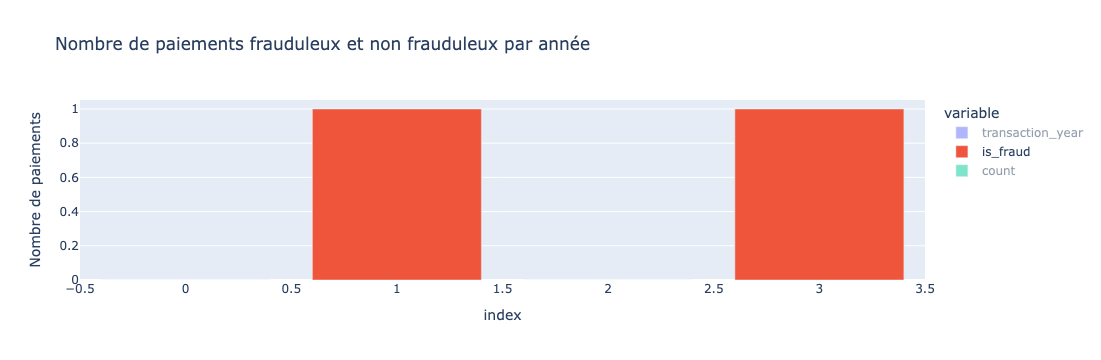

In [69]:
# Affichage du graphique
import plotly.express as px
fig = px.bar(transactions_by_year, 
             title="Nombre de paiements frauduleux et non frauduleux par année",
             labels={'transaction_year': 'Année', 'value': 'Nombre de paiements'})
fig.show()

## Montant moyen des transactions en fonction du métier 

In [35]:
# Montant moyen des transactions en fonction du métier 
avg_amount_by_job = df_credit_card.groupby('job')['amt'].mean()
avg_amount_by_job

job
Academic librarian                       69.623641
Accountant, chartered                   441.865000
Accountant, chartered certified          63.566300
Accountant, chartered public finance     54.749286
Accounting technician                    76.366863
                                           ...    
Water engineer                           79.972360
Water quality scientist                  72.807017
Web designer                             60.446684
Wellsite geologist                       64.980979
Writer                                   90.151584
Name: amt, Length: 493, dtype: float64

## Determiner le nombre de transaction par sex et par catégorie 

In [98]:
# Calculer le nombre de transactions par sexe et par catégorie de transaction
transactions_by_gender_and_category = df_credit_card.groupby(['gender', 'category']).size().reset_index(name='transaction_count')

# Afficher 
transactions_by_gender_and_category


,gender,category,transaction_count
0,F,entertainment,40811
1,F,food_dining,40880
2,F,gas_transport,61796
3,F,grocery_net,21240
4,F,grocery_pos,55182
5,F,health_fitness,38161
6,F,home,55031
7,F,kids_pets,53048
8,F,misc_net,29978
9,F,misc_pos,35902


# Etape 4 : Visualisation des tendances des différentes colonnes choisies en utilisant plusieurs types de graphiques


### Histogramme des transactions par heure 

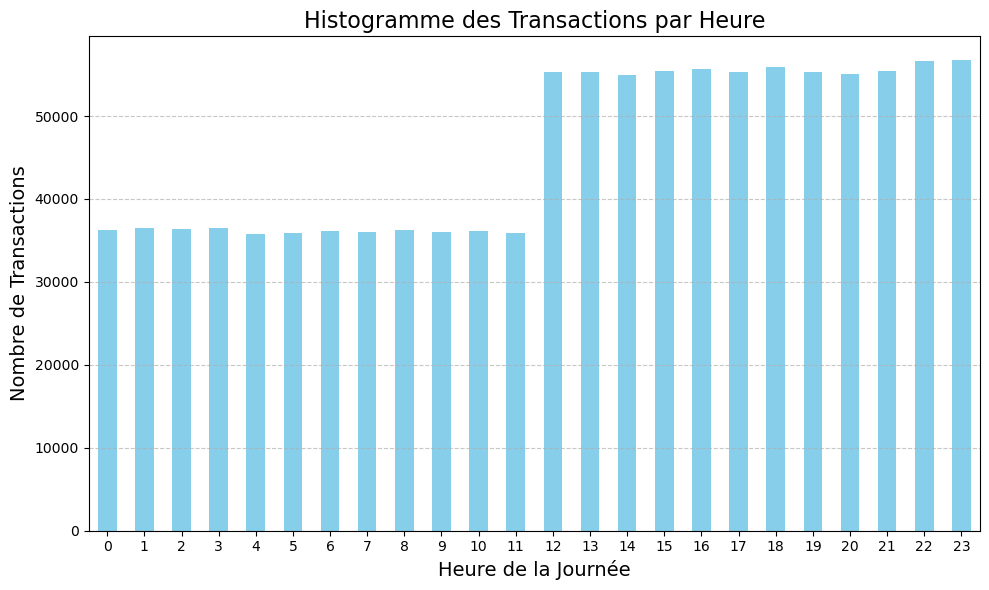

In [37]:
# Créer l'histogramme des transactions par heure
plt.figure(figsize=(10, 6))
df_credit_card['transaction_hour'].value_counts().sort_index().plot(kind='bar', color='skyblue')

# Ajouter des titres et étiquettes
plt.title('Histogramme des Transactions par Heure', fontsize=16)
plt.xlabel('Heure de la Journée', fontsize=14)
plt.ylabel('Nombre de Transactions', fontsize=14)
plt.xticks(rotation=0)

# Afficher le graphique
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Histogramme du nombre de transactions par Etat 

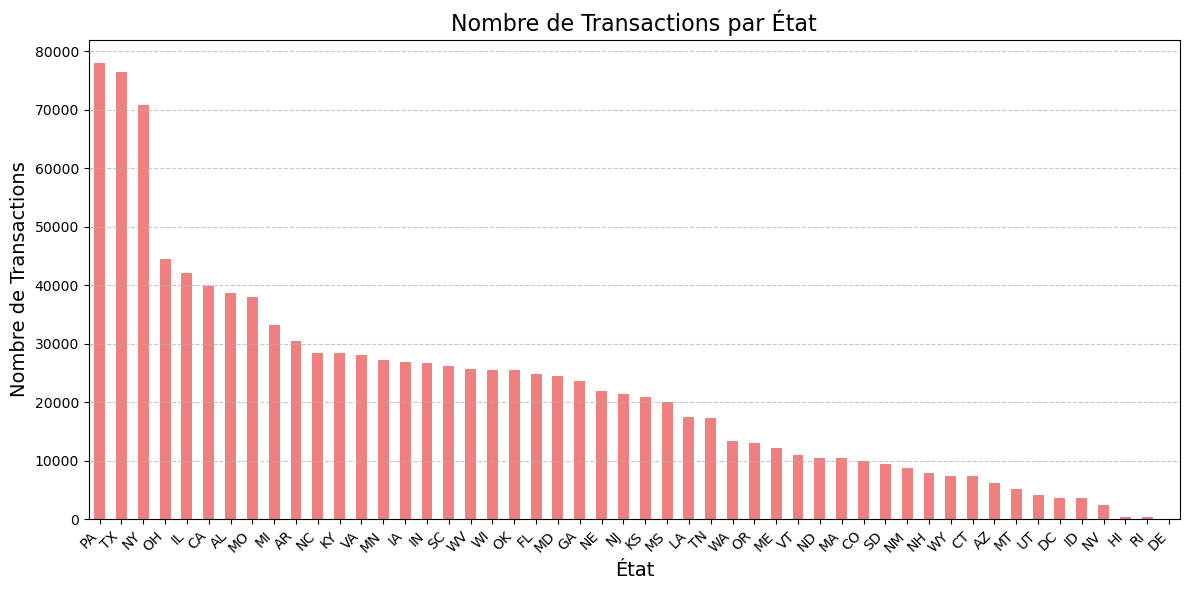

In [38]:
# Créer l'histogramme des transactions par État
plt.figure(figsize=(12, 6))
df_credit_card['state'].value_counts().plot(kind='bar', color='lightcoral')

# Ajouter des titres et étiquettes
plt.title('Nombre de Transactions par État', fontsize=16)
plt.xlabel('État', fontsize=14)
plt.ylabel('Nombre de Transactions', fontsize=14)
plt.xticks(rotation=45, ha='right')  # Rotation des noms d'états pour plus de lisibilité

# Ajouter une grille pour améliorer la lisibilité
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Afficher le graphique
plt.show()

## Diagramme du nombre de transaction par sex et catégorie de transaction 

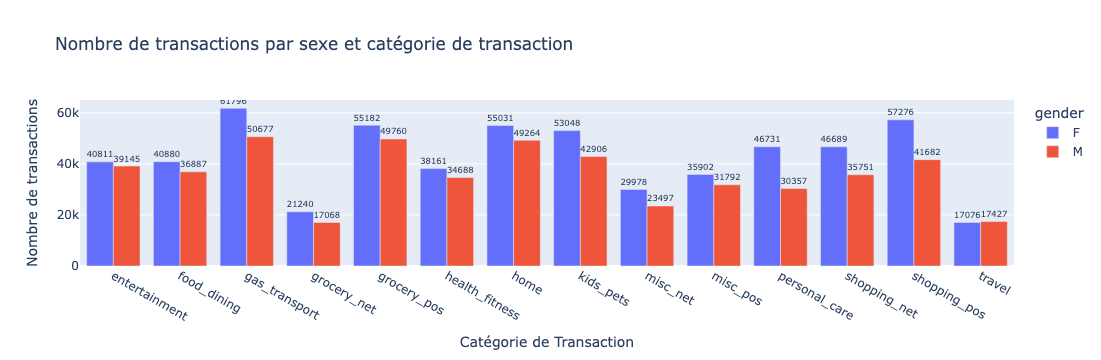

In [108]:
# Créer un graphique interactif (bar chart) pour visualiser les transactions par sexe et catégorie
fig6 = px.bar(transactions_by_gender_and_category,
             x='category', 
             y='transaction_count',
             color='gender',
             title='Nombre de transactions par sexe et catégorie de transaction',
             labels={'transaction_count': 'Nombre de transactions', 'category': 'Catégorie de Transaction'},
             barmode='group',
             text='transaction_count')  # Affiche la valeur sur chaque barre

# Mettre en forme le graphique
fig6.update_traces(texttemplate='%{text}', textposition='outside')  # Placer les valeurs au-dessus des barres

# Afficher le graphique
fig6.show()

Interprétation : Nous consations dans l'ensemble que les femmes depenses beaucoup plus que les hommes. Les frais liés au gaz,carburant sont à 61 796k contraiement aux frais des hommes siués à 50.677k.Suivi des depenses en magasion de 57 276k contre 41.682k pour les hommes. 

## Pie Chars ou diagramme circulaire du taux de fraude par catégorie de transaction

## Nombre de transactions frauduleuses et non frauduleuses par année 

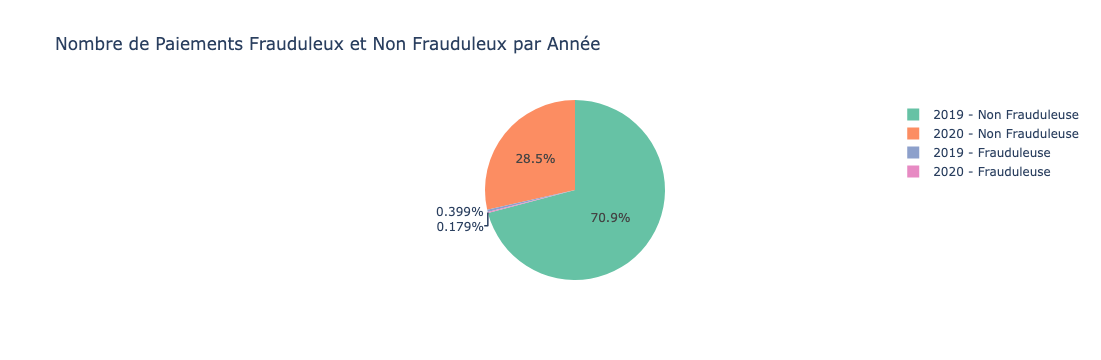

In [113]:
# Créer une table pour le graphique pie (transposer le pivot pour le rendre adapté à un pie chart)
transactions_by_year_pivot_reset = transactions_by_year_pivot.reset_index().melt(id_vars='transaction_year', 
                                                                                  value_vars=['Non Frauduleuse', 'Frauduleuse'],
                                                                                  var_name='Type de transaction', 
                                                                                  value_name='Nombre de paiements')

# Ajouter une colonne 'Année' et 'Type de Transaction' combinée pour un affichage spécifique
transactions_by_year_pivot_reset['Année et Type'] = transactions_by_year_pivot_reset['transaction_year'].astype(str) + ' - ' + transactions_by_year_pivot_reset['Type de transaction']

# Création du graphique interactif Pie
fig = px.pie(transactions_by_year_pivot_reset, 
             values='Nombre de paiements', 
             names='Année et Type', 
             color='Année et Type',
             color_discrete_sequence=px.colors.qualitative.Set2, 
             title="Nombre de Paiements Frauduleux et Non Frauduleux par Année",
             labels={'Nombre de paiements': 'Nombre', 'Année et Type': 'Année et Type de Transaction'})

fig.show()

In [ ]:
Interprétaion : 

## Taux de fraude par categorie de transaction

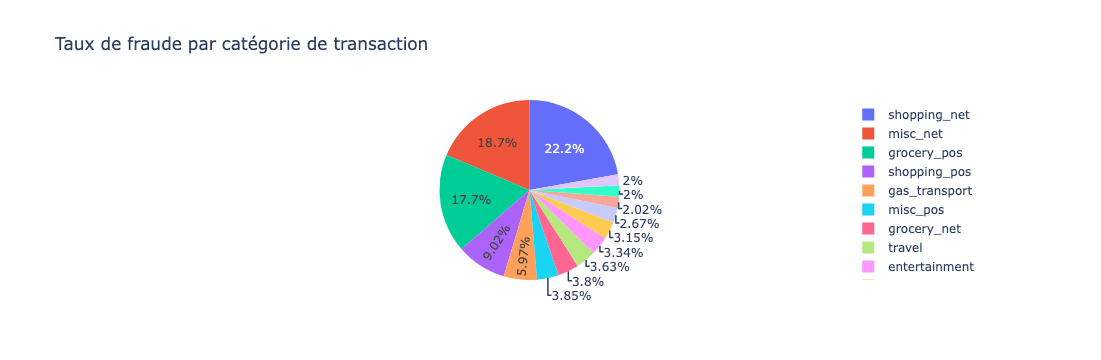

In [96]:
# Création du diagramme circulaire
fig1 = px.pie(
    fraud_rate_by_category_df, 
    values='fraud_rate', 
    names='category', 
    title='Taux de fraude par catégorie de transaction'
)

# Affichage du graphique
fig1.show()

Analyse : Le taux de fraude est plus élevé dans les transactions en ligne aux Etats unis atteignant les 22,2 % pour le shopping et 18,7% pour d'autres operations diverses en dehors du shopping, entertainement et food. : Ceci s'explique par la facilité de garder l'anonymat dans les achats en ligne. De nombreux achats en ligne se font egalement sans verification.Ces achats en lignes concernent les biens facilement revendage (gadgets electroniques). Les achats physiques reprsentent egalement une part considérable des trasanctions fraduleuses à hauteur de 17,7%.  

## Pie char ou histogramme du taux de fraude par tranche d'age 

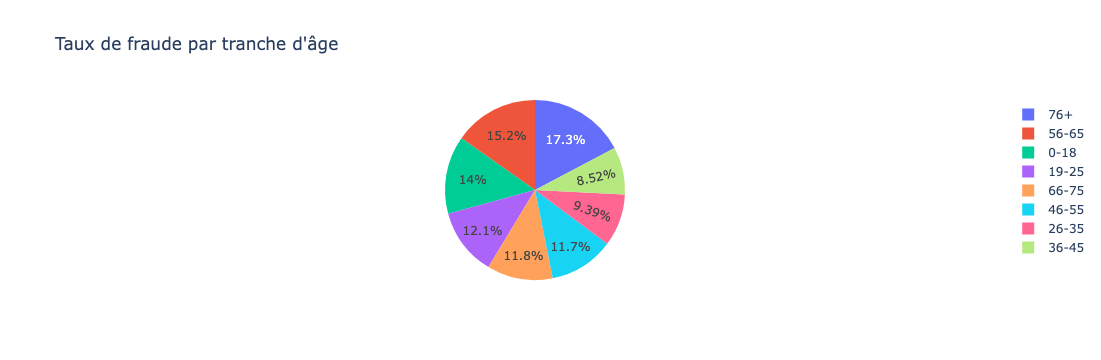

In [52]:
# Création du diagramme circulaire
fig2 = px.pie(fraud_rate_by_age, 
             values='fraud_rate', 
             names='category', 
             title="Taux de fraude par tranche d'âge")

fig2.show()

Analyse : Nous constatons que le taux de fraude est particulierement important pour les personnes agées de plus de 45 ans et atteignat un taux de 56,2% . Ceci s'explique par le fait qu'elles ne sont pas familières avec les technologique modernes comme les achats en ligne par carte de credit. Ce qui les rend plus suceptibles de tomber dans les pièges de fraude tels que les phishing et arnaques. Elles sont egalment exposées lors des chats en magasin. 

## Les commerçants les plus impliqués dans les transactions frauduleuses et non frauduleuses

In [61]:
# Séparer les transactions frauduleuses et non frauduleuses
fraudulent_transactions = df_credit_card[df_credit_card['is_fraud'] == 1]
non_fraudulent_transactions = df_credit_card[df_credit_card['is_fraud'] == 0]

# Compter les transactions par commerçant
top_merchants_fraud = fraudulent_transactions['merchant'].value_counts().head(10)
top_merchants_non_fraud = non_fraudulent_transactions['merchant'].value_counts().head(10)

# Créer un DataFrame pour comparaison
merchants_comparison = pd.DataFrame({
    'Commerçant': top_merchants_fraud.index.tolist() + top_merchants_non_fraud.index.tolist(),
    'Transactions Frauduleuses': list(top_merchants_fraud.values) + list(top_merchants_non_fraud.values),
    'Type de transaction': ['Frauduleuse'] * len(top_merchants_fraud) + ['Non frauduleuse'] * len(top_merchants_non_fraud)
})

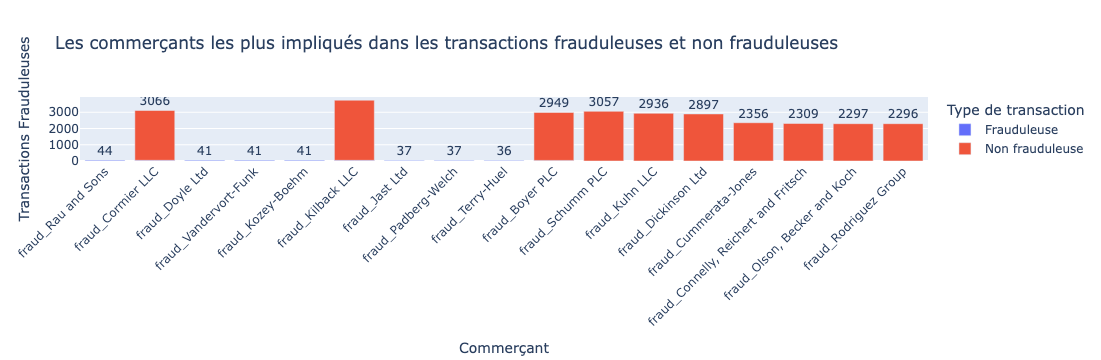

In [107]:
# Créer le graphique pour les commerçants
fig4 = px.bar(merchants_comparison, 
              x='Commerçant', 
              y='Transactions Frauduleuses', 
              color='Type de transaction',
              title="Les commerçants les plus impliqués dans les transactions frauduleuses et non frauduleuses",
              text='Transactions Frauduleuses')  # Afficher la valeur sur la barre

# Mettre en forme le graphique
fig4.update_layout(xaxis_tickangle=-45)
fig4.update_traces(texttemplate='%{text}', textposition='outside') # Placer le texte au-dessus des barres

fig4.show()

## Les États les plus impliqués dans les transactions frauduleuses et non frauduleuses

In [105]:
# Séparer les transactions frauduleuses et non frauduleuses
fraudulent_transactions = df_credit_card[df_credit_card['is_fraud'] == 1]
non_fraudulent_transactions = df_credit_card[df_credit_card['is_fraud'] == 0]

# Compter les transactions par état
top_states_fraud = fraudulent_transactions['state'].value_counts().head(10)
top_states_non_fraud = non_fraudulent_transactions['state'].value_counts().head(10)

# Créer un DataFrame pour comparaison
states_comparison = pd.DataFrame({
    'État': top_states_fraud.index.tolist() + top_states_non_fraud.index.tolist(),
    'Transactions Frauduleuses': list(top_states_fraud.values) + list(top_states_non_fraud.values),
    'Type de transaction': ['Frauduleuse'] * len(top_states_fraud) + ['Non frauduleuse'] * len(top_states_non_fraud)
})

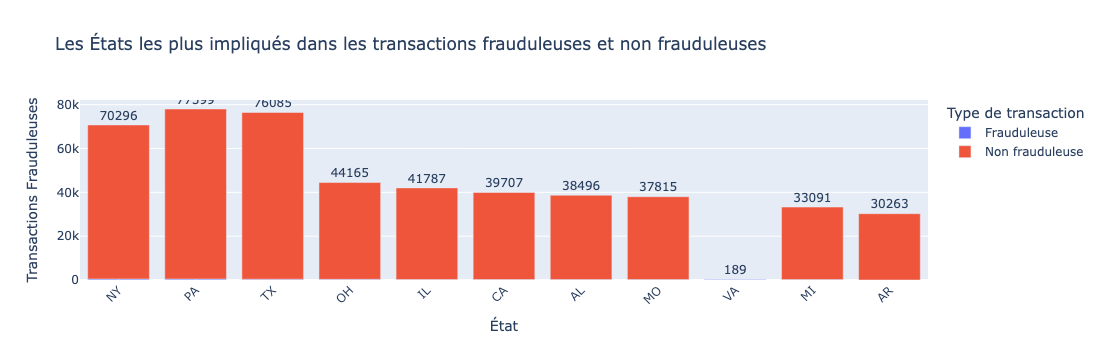

In [106]:
# Créer le graphique
fig5 = px.bar(states_comparison, 
              x='État', 
              y='Transactions Frauduleuses', 
              color='Type de transaction',
              title="Les États les plus impliqués dans les transactions frauduleuses et non frauduleuses",
              text='Transactions Frauduleuses')  # Afficher la valeur sur la barre

# Mettre en forme le graphique
fig5.update_layout(xaxis_tickangle=-45)
fig5.update_traces(texttemplate='%{text}', textposition='outside')  # Placer le texte au-dessus des barres

fig5.show()


#  Etape 5. Récupération de larticle et Création d’un wordcloud basé l'article une fois traité

## Etape 5.1 - Le préprocessing

### Importation de l'article et exploration

###Convertir l'article au fichier csv 

In [154]:
# Structuration de l'article dans un dictionnaire
data = {
    'Titre': ['ARNAQUE A LA COPIE DE CB : ATTENTION A CETTE ESCROQUERIE QUI A TOUCHE DE NOMBREUX FRANÇAIS'],
    'Texte': [
        """
        Dans la région de Toulouse, trois individus ont été arrêtés courant novembre pour pratique de «skimming», une méthode de fraude bancaire qui a touché beaucoup de français ces dernières années. En quoi consiste-t-elle ? 
        Opération réussie. Du côté de Toulouse, l’antenne cyber de la Section de recherches (SR) a démantelé un réseau d'escroquerie à la carte bancaire, a annoncé la gendarmerie ce samedi 30 novembre. Les accusés étaient passés expert dans la pratique du «Skimming».
        Après l'arrestation de «trois ressortissants de l'Est» dans la région de Toulouse pour fraude à la carte bancaire, les autorités alertent sur le «skimming» dans Toulouse Actu. «L’escroquerie par skimming consiste à cloner une carte bancaire, en trafiquant ou en piratant des terminaux de paiement, dans lesquels cette carte peut être insérée, comme des distributeurs de billets ou des automates de station-service, a expliqué la gendarmerie nationale. Les données sont ensuite dupliquées sur une autre carte à puce, permettant ainsi d’accéder aux comptes bancaires reliés à la carte.
        Dans la majorité des cas, les fraudeurs trafiquent des terminaux de paiements comme des distributeurs de billets ou encore des automates installés dans les stations-services afin de copier les données bancaires sur la bande magnétique. Elles sont ensuite transférées sur une autre puce qui agit comme une copie de votre carte.
        Le skimmer est «un matériel se glissant dans la fente d’un automate tout en laissant de l’espace pour qu’une carte bancaire puisse y être glissée naturellement», indiquaient l'Observatoire de la sécurité des moyens de paiement (OSMP) en 2023. La copie des données bancaires n'empêche pas le bon fonctionnement de votre carte.
        """
    ],
    'Date de publication': ['03/12/2024'],
    'Source': ['CNEWS']
}

# Création du DataFrame à partir du dictionnaire
df = pd.DataFrame(data)

# Exporter le DataFrame en CSV
df.to_csv('article_cnews.csv', index=False, encoding='utf-8')

# Afficher un message de confirmation
print("Le fichier CSV a été créé avec succès.")


Le fichier CSV a été créé avec succès.


### Importation du fihier csv 

In [156]:
article = pd.read_csv("article_cnews.csv", delimiter=';')

print(f"la table fait {df.shape[0]} lignes et {df.shape[1]} colonnes" )

article

la table fait 1 lignes et 4 colonnes


,"Titre,Texte,Date de publication,Source"
0,ARNAQUE A LA COPIE DE CB : ATTENTION A CETTE E...
1,"Dans la région de Toulouse, trois indi..."
2,Opération réussie. Du côté de Toulouse...
3,Après l'arrestation de «trois ressorti...
4,"Dans la majorité des cas, les fraudeur..."
5,Le skimmer est «un matériel se glissan...
6,""",03/12/2024,CNEWS"


### Analyse de la composition de l'article_card 

In [157]:
i = 1

for doc in article:
    print(f"L'article {i} est de longueur : {len(doc)}")
    i+=1

Le document 1 est de longueur : 38


In [163]:
print(f"L'aticle est composé de {len(article)} ligne")

L'aticle est composé de 7 ligne


In [ ]:
Le nombre de mots dans chacun de ces documents :

In [162]:
i = 1

for doc in article:
    liste_mots = doc.split() # Permet de séparer les mots d'une chaines de caractère en fonction d'un séparateur 
                             # par défault l'espace.
        
    print(f"La premiere {i} contient {len(liste_mots)} mots")
    print(f"La liste de de la premiere ligne {i} : {liste_mots} \n")
    i+=1

La premiere 1 contient 3 mots
La liste de de la premiere ligne 1 : ['Titre,Texte,Date', 'de', 'publication,Source'] 

